# 04. 이상치 탐지
비정상적인 이용 패턴(이상 트립, 이상 대여소 시간대)을 탐지합니다.

In [1]:
import sys, gc, joblib
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from src.data_loader import load_processed, save_processed
from src.feature_engineering import build_trip_features
from src.evaluation import plot_anomaly_timeline
print("\u2705 준비 완료")

✅ 준비 완료


## 1. 데이터 로드 및 약지도 이상치 정의

In [2]:
df = load_processed("rentals_clean")
df = build_trip_features(df)

# 약지도(rule-based) 이상치 레이블 정의 (평가용)
conditions = (
    (df["speed_kmh"] > 35) |                               # 너무 빠른 속도
    ((df["use_m"] > 500) & (df["use_min"] < 1)) |          # 짧은 시간 + 긴 거리
    (df["use_min"] > 360) |                                # 6시간 초과
    ((df["use_m"] == 0) & (df["use_min"] > 30))            # 거리 없는데 30분 초과
)
df["weak_label"] = conditions.astype(int)
print(f"약지도 이상치 수: {df['weak_label'].sum():,}  ({df['weak_label'].mean()*100:.2f}%)")

# 통계 요약
print("\n이상치 vs 정상 비교:")
print(df.groupby("weak_label")[["use_min", "use_m", "speed_kmh"]].mean().round(2))

📂 Loaded rentals_clean.parquet → shape: (8559939, 27)


약지도 이상치 수: 23,024  (0.27%)

이상치 vs 정상 비교:


            use_min    use_m  speed_kmh
weak_label                             
0             19.75  2158.72       8.36
1             75.88  1141.04       8.58


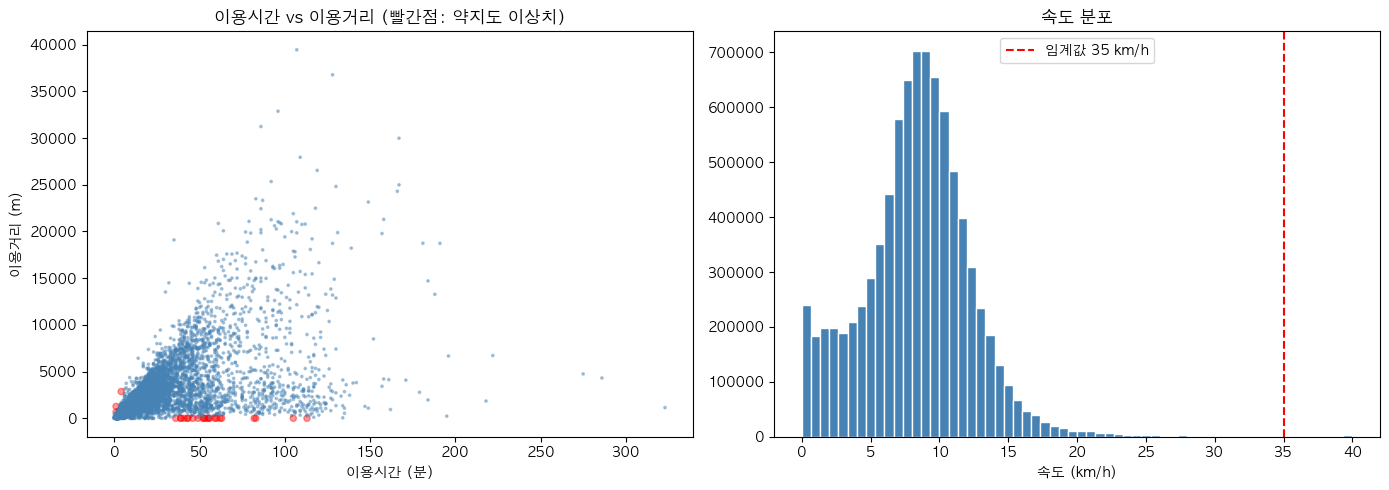

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 이용시간 vs 이용거리 산점도
sample = df.sample(min(10000, len(df)), random_state=42)
colors = ["steelblue" if l == 0 else "red" for l in sample["weak_label"]]
sizes  = [3 if l == 0 else 20 for l in sample["weak_label"]]
axes[0].scatter(sample["use_min"], sample["use_m"], c=colors, s=sizes, alpha=0.4)
axes[0].set_title("이용시간 vs 이용거리 (빨간점: 약지도 이상치)")
axes[0].set_xlabel("이용시간 (분)")
axes[0].set_ylabel("이용거리 (m)")

# 속도 분포
axes[1].hist(df["speed_kmh"].dropna(), bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(35, color="red", linestyle="--", label="임계값 35 km/h")
axes[1].set_title("속도 분포")
axes[1].set_xlabel("속도 (km/h)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/anomaly_overview.png", dpi=150)
plt.show()

## 2. Isolation Forest

In [4]:
# 피처 선택 및 정규화
FEAT_COLS = ["use_min", "use_m", "speed_kmh", "hour", "dow"]
df_iso = df[FEAT_COLS + ["weak_label"]].dropna()

sample_n = min(200_000, len(df_iso))
df_sample = df_iso.sample(n=sample_n, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[FEAT_COLS])

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_scaled)

df_sample = df_sample.copy()
df_sample["iso_score"]  = -iso_forest.score_samples(X_scaled)  # 높을수록 이상
df_sample["iso_label"]  = (iso_forest.predict(X_scaled) == -1).astype(int)

print(f"Isolation Forest 탐지 이상치: {df_sample['iso_label'].sum():,}개")

# 약지도 레이블과 비교
from sklearn.metrics import classification_report as sk_cr
print("\n약지도 레이블 대비 평가:")
print(sk_cr(df_sample["weak_label"], df_sample["iso_label"], target_names=["정상", "이상치"]))

Isolation Forest 탐지 이상치: 4,000개

약지도 레이블 대비 평가:
              precision    recall  f1-score   support

          정상       1.00      0.98      0.99    199434
         이상치       0.02      0.16      0.04       566

    accuracy                           0.98    200000
   macro avg       0.51      0.57      0.51    200000
weighted avg       0.99      0.98      0.99    200000



In [5]:
# LOF (작은 샘플에서만)
lof_n = min(20_000, len(df_sample))
df_lof = df_sample.head(lof_n).copy()
X_lof = scaler.transform(df_lof[FEAT_COLS])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02, n_jobs=-1)
lof_labels = (lof.fit_predict(X_lof) == -1).astype(int)

df_lof["lof_label"] = lof_labels
df_lof["lof_score"] = -lof.negative_outlier_factor_

print(f"LOF 탐지 이상치: {lof_labels.sum():,}개")
print("\nLOF 약지도 레이블 대비 평가:")
print(sk_cr(df_lof["weak_label"], df_lof["lof_label"], target_names=["정상", "이상치"]))

LOF 탐지 이상치: 400개

LOF 약지도 레이블 대비 평가:
              precision    recall  f1-score   support

          정상       1.00      0.98      0.99     19950
         이상치       0.05      0.38      0.08        50

    accuracy                           0.98     20000
   macro avg       0.52      0.68      0.54     20000
weighted avg       1.00      0.98      0.99     20000



## 3. 대여소 시계열 이상치 (STL 분해)

📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)


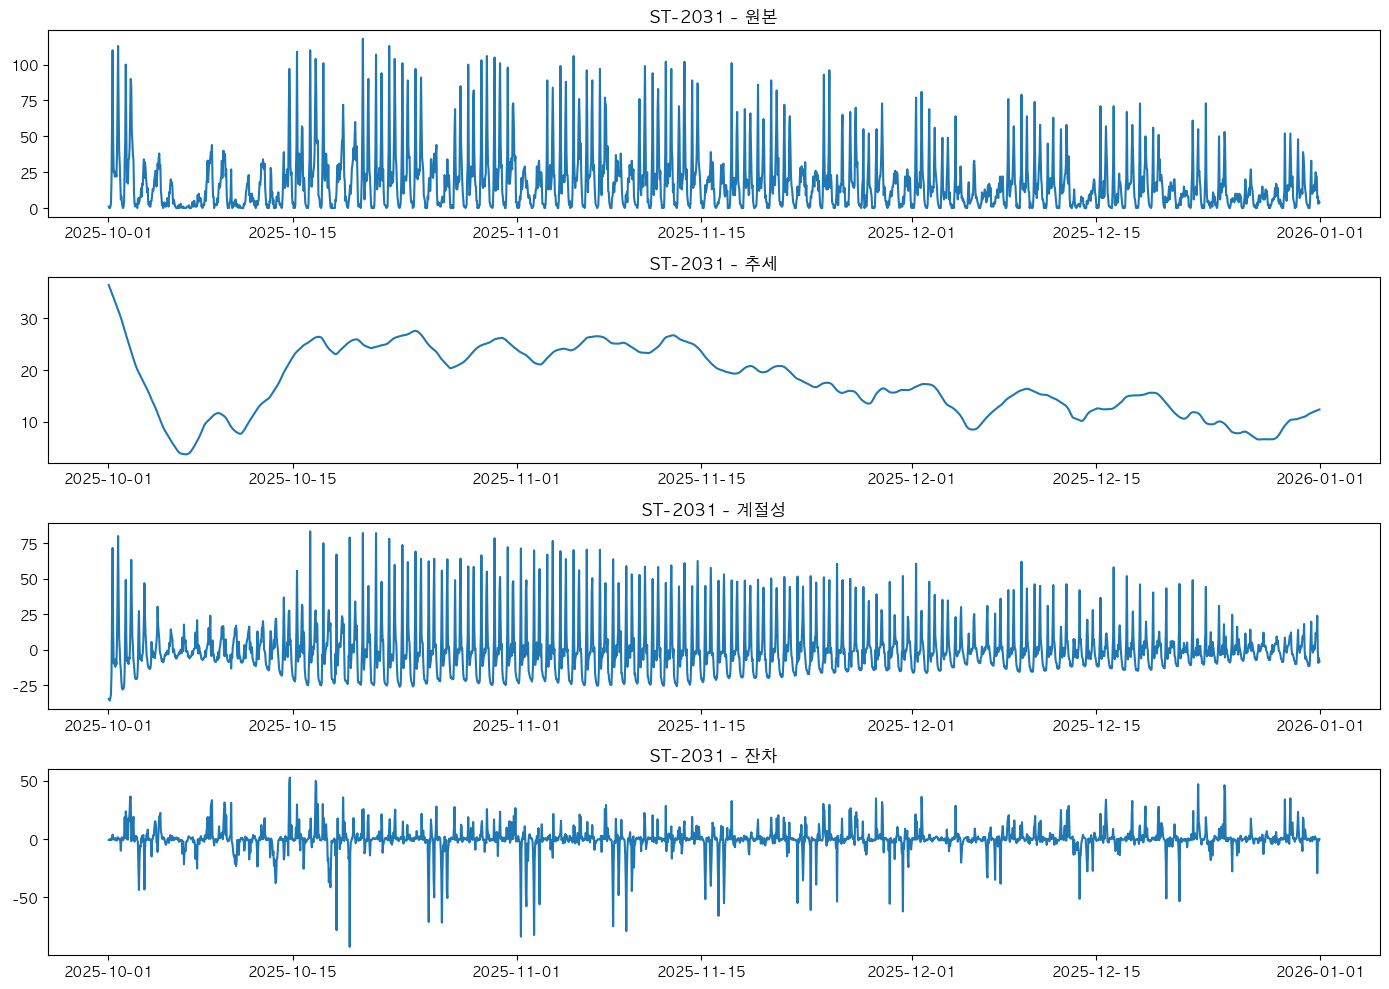

STL 잔차 이상치 시간: 58개
datetime_hour
2025-10-02 16:00:00    36.491711
2025-10-02 17:00:00    36.577414
2025-10-03 08:00:00   -43.716469
2025-10-03 18:00:00   -43.209658
2025-10-13 17:00:00   -37.763604
2025-10-13 18:00:00   -35.669196
2025-10-14 18:00:00    47.972680
2025-10-14 19:00:00    52.903825
2025-10-16 18:00:00    49.987336
2025-10-16 19:00:00    49.002803
2025-10-17 18:00:00   -36.974560
2025-10-17 21:00:00   -41.383094
2025-10-18 08:00:00   -78.200662
2025-10-18 20:00:00    35.864255
2025-10-19 08:00:00   -92.470960
2025-10-25 07:00:00   -36.642318
2025-10-25 08:00:00   -71.168959
2025-10-25 17:00:00   -35.582755
2025-10-25 18:00:00   -49.944277
2025-10-26 08:00:00   -71.762460
2025-10-26 17:00:00   -44.068827
2025-10-26 18:00:00   -50.603692
2025-11-01 08:00:00   -83.743277
2025-11-01 17:00:00   -46.394778
2025-11-01 18:00:00   -57.695336
2025-11-02 08:00:00   -82.377105
2025-11-02 18:00:00   -55.965758
2025-11-08 07:00:00   -35.539068
2025-11-08 08:00:00   -74.869069
2025-11-08

In [6]:
from statsmodels.tsa.seasonal import STL

hourly = load_processed("station_hourly_demand")

# 상위 대여소 1개 선택
top_stn = hourly.groupby("stn_id")["rent_count"].sum().idxmax()
stn_ts = hourly[hourly["stn_id"] == top_stn].set_index("datetime_hour")["rent_count"]
stn_ts = stn_ts.asfreq("h").fillna(0)

# STL 분해 (period=24: 하루 주기)
if len(stn_ts) >= 48:  # 최소 2일 이상의 데이터가 있어야 함
    stl = STL(stn_ts, period=24, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    for ax, data, title in zip(axes,
                                [stn_ts, result.trend, result.seasonal, result.resid],
                                ["원본", "추세", "계절성", "잔차"]):
        ax.plot(data)
        ax.set_title(f"{top_stn} - {title}")
    plt.tight_layout()
    plt.savefig("../reports/figures/stl_decomposition.png", dpi=150)
    plt.show()

    # 잔차 기반 이상치 탐지
    resid_std = result.resid.std()
    anomaly_mask = np.abs(result.resid) > 3 * resid_std
    print(f"STL 잔차 이상치 시간: {anomaly_mask.sum()}개")
    print(result.resid[anomaly_mask])
else:
    print("데이터가 부족하여 STL 분해를 건너뜁니다.")

## 4. 이상치 점수 저장

In [7]:
# 이상치 점수를 원본 데이터에 조인 (Isolation Forest)
df_out = df.copy()
iso_scores = pd.Series(df_sample["iso_score"].values, index=df_sample.index, name="iso_anomaly_score")
df_out = df_out.join(iso_scores, how="left")
df_out["iso_anomaly_score"] = df_out["iso_anomaly_score"].fillna(0)

save_processed(df_out, "trip_anomaly_scores")

# 모델 저장
model_dir = Path("../models/anomaly")
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(iso_forest, model_dir / "isolation_forest.pkl")
joblib.dump(scaler, model_dir / "scaler.pkl")
print("\u2705 이상치 탐지 모델 저장 완료")

💾 Saved → /Users/hayoung/seoul-bike-ml/data/processed/trip_anomaly_scores.parquet  (332.1 MB)
✅ 이상치 탐지 모델 저장 완료
